In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import streamlit as st
st.write("DEBUG: Script is executing")
st.title("EV Range Prediction")

@st.cache_resource
def load_model():
    return joblib.load("ev_range_prediction_pipeline.joblib")

with st.spinner("Loading model pipeline..."):
    model = load_model()

st.success("Model loaded!")



In [5]:
df=pd.read_excel(r"C:\Users\Sachin\.anaconda\contestset.xls")

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
number_of_cells              202
towing_capacity_kg            26
torque_nm                      7
model                          1
fast_charging_power_kw_dc      1
fast_charge_port               1
cargo_volume_l                 1
dtype: int64


In [7]:
df["fast_charge_port"].value_counts()


fast_charge_port
CCS        476
CHAdeMO      1
Name: count, dtype: int64

In [8]:
df["battery_type"].value_counts()

battery_type
Lithium-ion    478
Name: count, dtype: int64

In [9]:
print((df["number_of_cells"].isnull().sum())/len(df)*100)

42.25941422594142


In [10]:
#As we can see the above two features "battery_type" and "fast_charge_port" have nearly zero variance.
#therefore they can cause overfitting. that is why we need to remove them from the training set.
#number_of_cells is nearly 42.3% empty so we can impute it with median and create a binary flag column indicating whether the original value was missing.  

In [11]:
def clean_input_data(X):
    X = X.copy()
    if 'cargo_volume_l' in X.columns:
        X['cargo_volume_l'] = pd.to_numeric(X['cargo_volume_l'], errors='coerce')
   
    cats = ['drivetrain', 'segment', 'car_body_type', 'brand', 'model']
    for col in cats:
        if col in X.columns:
            X[col] = X[col].astype(str)
            
    return X

In [12]:
#This function handles the string values inside the numeric column 'cargo_volume_l;

In [13]:
if {"length_mm", "width_mm", "height_mm"}.issubset(df.columns):
        df['volumetric_footprint'] = (df["length_mm"] * df["width_mm"] * df["height_mm"]) / 1e9

In [14]:
if {"battery_capacity_kWh", "torque_nm"}.issubset(df.columns):
    df["battery_to_torque_ratio"] = df["battery_capacity_kWh"] / df["torque_nm"]

In [15]:
y=df["range_km"]
X=df.drop(columns=["range_km","efficiency_wh_per_km","source_url","fast_charge_port"])

In [16]:
numeric_feature_flagged=["number_of_cells"]
numeric_features=["battery_capacity_kWh", "torque_nm",
                  "efficiency_wh_per_km", "top_speed_kmh", "acceleration_0_100_s", 
                  "fast_charging_power_kw_dc", "towing_capacity_kg", "cargo_volume_l","seats", 
                  "length_mm", "width_mm", "height_mm","volumetric_footprint","battery_to_torque_ratio"]
cate_features=["brand", "model", "drivetrain", "segment", "car_body_type"]

In [17]:
numeric_pipeline_flagged=Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])
numeric_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median', add_indicator=False)),
    ('scaler', StandardScaler())
])
cate_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    
])
preprocessor=ColumnTransformer([
    ('num_flagged',numeric_pipeline_flagged,numeric_feature_flagged),
    ('num',numeric_pipeline,numeric_features),
    ('cate',cate_pipeline,cate_features)
])
model_pipeline=Pipeline([
    ('valid_input', FunctionTransformer(clean_input_data)),
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [6, 10, 14, None],
    'model__min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    error_score='raise'
)

all_features =numeric_feature_flagged+numeric_features+cate_features
    

In [18]:
X=df[all_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# 1. Fit GridSearch on training data
grid_search.fit(X_train, y_train)

# 2. Print optimal parameters and cross-validation score
print("Best Hyperparameters:", grid_search.best_params_)


# 3. Extract and save winning pipeline
best_pipeline = grid_search.best_estimator_
joblib.dump(best_pipeline, 'ev_range_pipeline.joblib')

Best Hyperparameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 50}


['ev_range_pipeline.joblib']

In [20]:
# 1. Predict on the holdout test set using your best tuned pipeline
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

# 2. Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE):     {mae:.2f} km")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} km")

Mean Absolute Error (MAE):     15.30 km
Root Mean Squared Error (RMSE): 21.41 km


In [21]:
import joblib

# 1. Extract the best estimator pipeline from grid search
final_pipeline = grid_search.best_estimator_

# 2. Retrain the complete pipeline on the ENTIRE dataset (X, y)
final_pipeline.fit(X, y)

# 3. Export the unified preprocessor + model artifact
model_filename = 'ev_range_prediction_pipeline.joblib'
joblib.dump(final_pipeline, model_filename)

print(f"Pipeline successfully serialized and saved to '{model_filename}'")

# --- Example: Loading and Incomplete Raw Data Inference ---
# Load pipeline back from disk
loaded_pipeline = joblib.load(model_filename)

# Pass raw Pandas DataFrame (unprocessed) directly into .predict()
# loaded_pipeline.predict(raw_new_ev_dataframe)

Pipeline successfully serialized and saved to 'ev_range_prediction_pipeline.joblib'


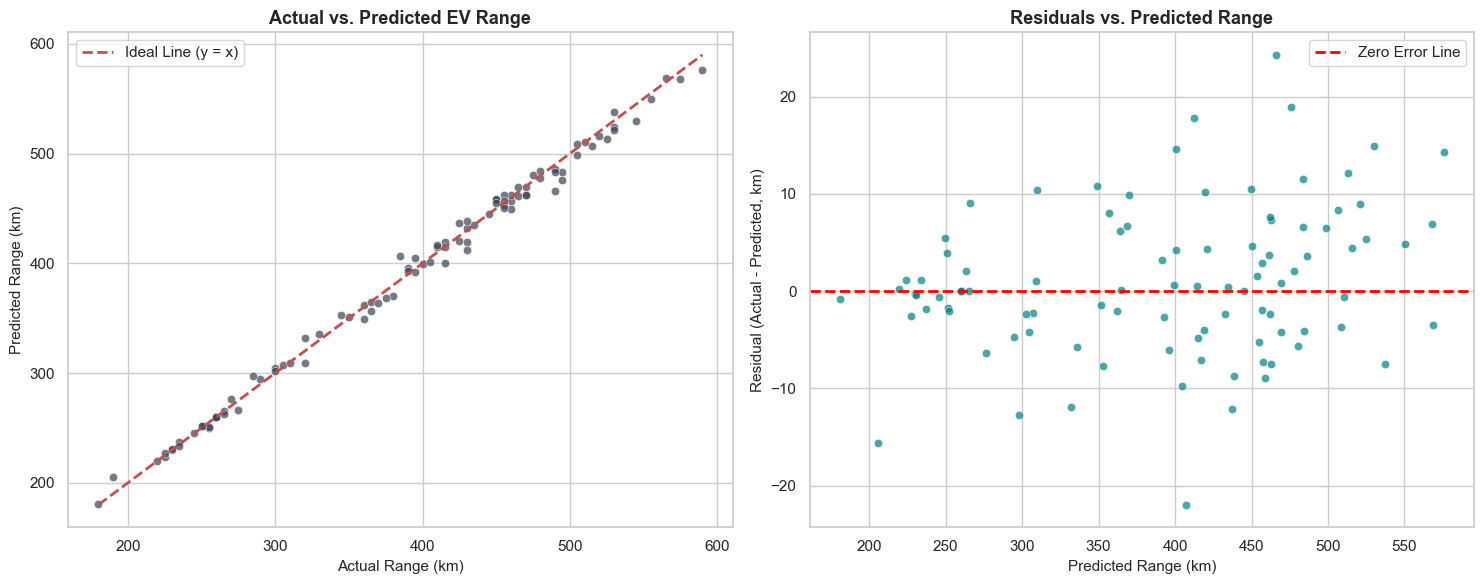

In [22]:


# 1. Compute predictions and residuals on test data
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
residuals = y_test - y_pred

# 2. Set up side-by-side diagnostic subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot 1: Actual vs. Predicted Range ---
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='#3B4252', ax=axes[0])

# Perfect prediction identity line y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Line (y = x)')

axes[0].set_title('Actual vs. Predicted EV Range', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Range (km)', fontsize=11)
axes[0].set_ylabel('Predicted Range (km)', fontsize=11)
axes[0].legend()

# --- Subplot 2: Residual Plot (Error vs Prediction) ---
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='#008080', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

axes[1].set_title('Residuals vs. Predicted Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Range (km)', fontsize=11)
axes[1].set_ylabel('Residual (Actual - Predicted, km)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

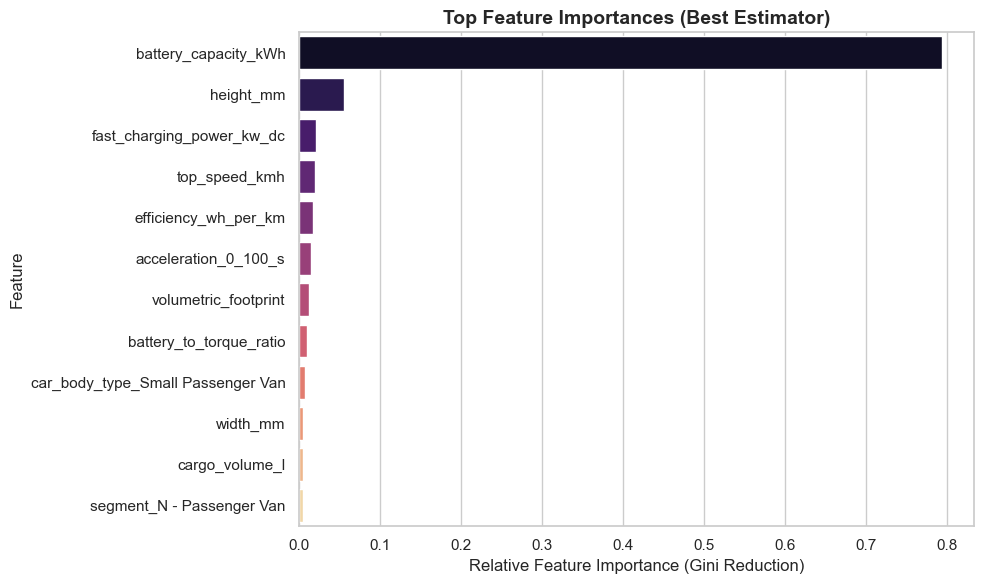

Custom Feature Contribution
                Feature  Importance
   volumetric_footprint    0.012548
battery_to_torque_ratio    0.010147


In [26]:


# 1. Access preprocessor and regressor from best grid search pipeline
best_pipeline = grid_search.best_estimator_
preprocessor = best_pipeline.named_steps['preprocessor']
regressor = best_pipeline.named_steps['model']

# 2. Extract feature names output by ColumnTransformer
raw_feature_names = preprocessor.get_feature_names_out()

# Clean transformer prefixes (e.g., converts 'num__battery_capacity' to 'battery_capacity')
clean_feature_names = [f.split('__')[-1] for f in raw_feature_names]

# 3. Create DataFrame and sort by importance weight
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Plot top feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(12),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)
plt.title('Top Feature Importances (Best Estimator)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance (Gini Reduction)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Verify performance of engineered proxy features
Custom_features = ['battery_to_torque_ratio', 'volumetric_footprint']
print("Custom Feature Contribution")
print(importance_df[importance_df['Feature'].isin(Custom_features)].to_string(index=False))

In [ ]:
# Figure Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Target Distribution Analysis 
skewness = df['range_km'].skew()
sns.histplot(df['range_km'], kde=True, color='skyblue', bins=30, ax=axes[0])
axes[0].axvline(df['range_km'].mean(), color='red', linestyle='--', label=f'Mean ({df["range_km"].mean():.1f} km)')
axes[0].axvline(df['range_km'].median(), color='green', linestyle='-', label=f'Median ({df["range_km"].median():.1f} km)')
axes[0].set_title(f'Target Distribution: range_km (Skewness: {skewness:.2f})', fontsize=12)
axes[0].set_xlabel('Range (km)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Action 2: Feature Correlation Heatmap 
# Select continuous numerical columns and exclude target leakage feature 'efficiency_wh_per_km'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_features = [col for col in numeric_cols if col != 'efficiency_wh_per_km']

corr_matrix = df[candidate_features].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=axes[1],
    cbar_kws={'label': 'Pearson Correlation'}
)
axes[1].set_title('Continuous Feature Correlation Heatmap', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#Skewness: =0.16 (fairly symmetrical; log transformation is not required).
#Strongest Positive Predictor: battery_capacity_kWh has the highest correlation with range_km (r = 0.88), followed by top_speed_kmh (r = 0.73) and fast_charging_power_kw_dc (r = 0.72).
#Strongest Inverse Predictor: acceleration_0_100_s (r = -0.71), indicating faster acceleration times (lower values) correlate with higher range.